<a href="https://colab.research.google.com/github/sachinthadilshann/pytorch_course_by_DanielBourke/blob/main/06_PyTorch_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#6. Pytorch transfer learning

In [145]:
import torch
import torchvision

print(f"torch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")


torch version: 2.11.0+cu128
torchvision version: 0.26.0+cu128


In [146]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [147]:
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms


try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary


try:
    from going_modular.going_modular import data_setup, engine
except:

    print("[INFO] Couldn't find going_modular scripts... downloading them from GitHub.")
    !git clone https://github.com/sachinthadilshann/pytorch_course_by_DanielBourke/
    !mv pytorch_course_by_DanielBourke/going_modular .
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine

In [148]:
import os
import zipfile

from pathlib import Path

import requests

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"


if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...")
        zip_ref.extractall(image_path)

    # Remove .zip file
    os.remove(data_path / "pizza_steak_sushi.zip")

data/pizza_steak_sushi directory exists.


In [149]:
train_dir = image_path / "train"
test_dir = image_path / "test"

In [150]:
from going_modular.going_modular import data_setup

##Creating a transform for torchvision.models (auto creation)

In [151]:
from torchvision.models import resnet50, ResNet50_Weights

# Get a set of pretrained model weights
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT # .DEFAULT(best available weights from pretraining on ImageNet)
weights

EfficientNet_B0_Weights.IMAGENET1K_V1

In [152]:
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [153]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

# Define data augmentation for training. Use auto_transforms as base.
train_transforms = transforms.Compose([
    transforms.TrivialAugmentWide(num_magnitude_bins=31), # Add data augmentation
    auto_transforms # Apply standard transforms after augmentation
])

test_transforms = auto_transforms

# Create datasets
train_data = datasets.ImageFolder(root=train_dir, transform=train_transforms)
test_data = datasets.ImageFolder(root=test_dir, transform=test_transforms)

# Get class names
class_names = train_data.classes

# Create dataloaders
BATCH_SIZE = 32
train_dataloader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=os.cpu_count(),
    pin_memory=True,
)

test_dataloader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=os.cpu_count(),
    pin_memory=True,
)

print(f"Number of training samples: {len(train_data)}")
print(f"Number of testing samples: {len(test_data)}")
print(f"Class names: {class_names}")

Number of training samples: 225
Number of testing samples: 75
Class names: ['pizza', 'steak', 'sushi']


##getting pretrained model

In [154]:
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
model = torchvision.models.efficientnet_b0(weights=weights).to(device)

In [155]:
'''
weights_1 = torchvision.models.EfficientNet_V2_S_Weights.IMAGENET1K_V1.DEFAULT
model_1 = torchvision.models.efficientnet_v2_s(weights=weights_1).to(device)
'''

'\nweights_1 = torchvision.models.EfficientNet_V2_S_Weights.IMAGENET1K_V1.DEFAULT\nmodel_1 = torchvision.models.efficientnet_v2_s(weights=weights_1).to(device)\n'

In [156]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [157]:
model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

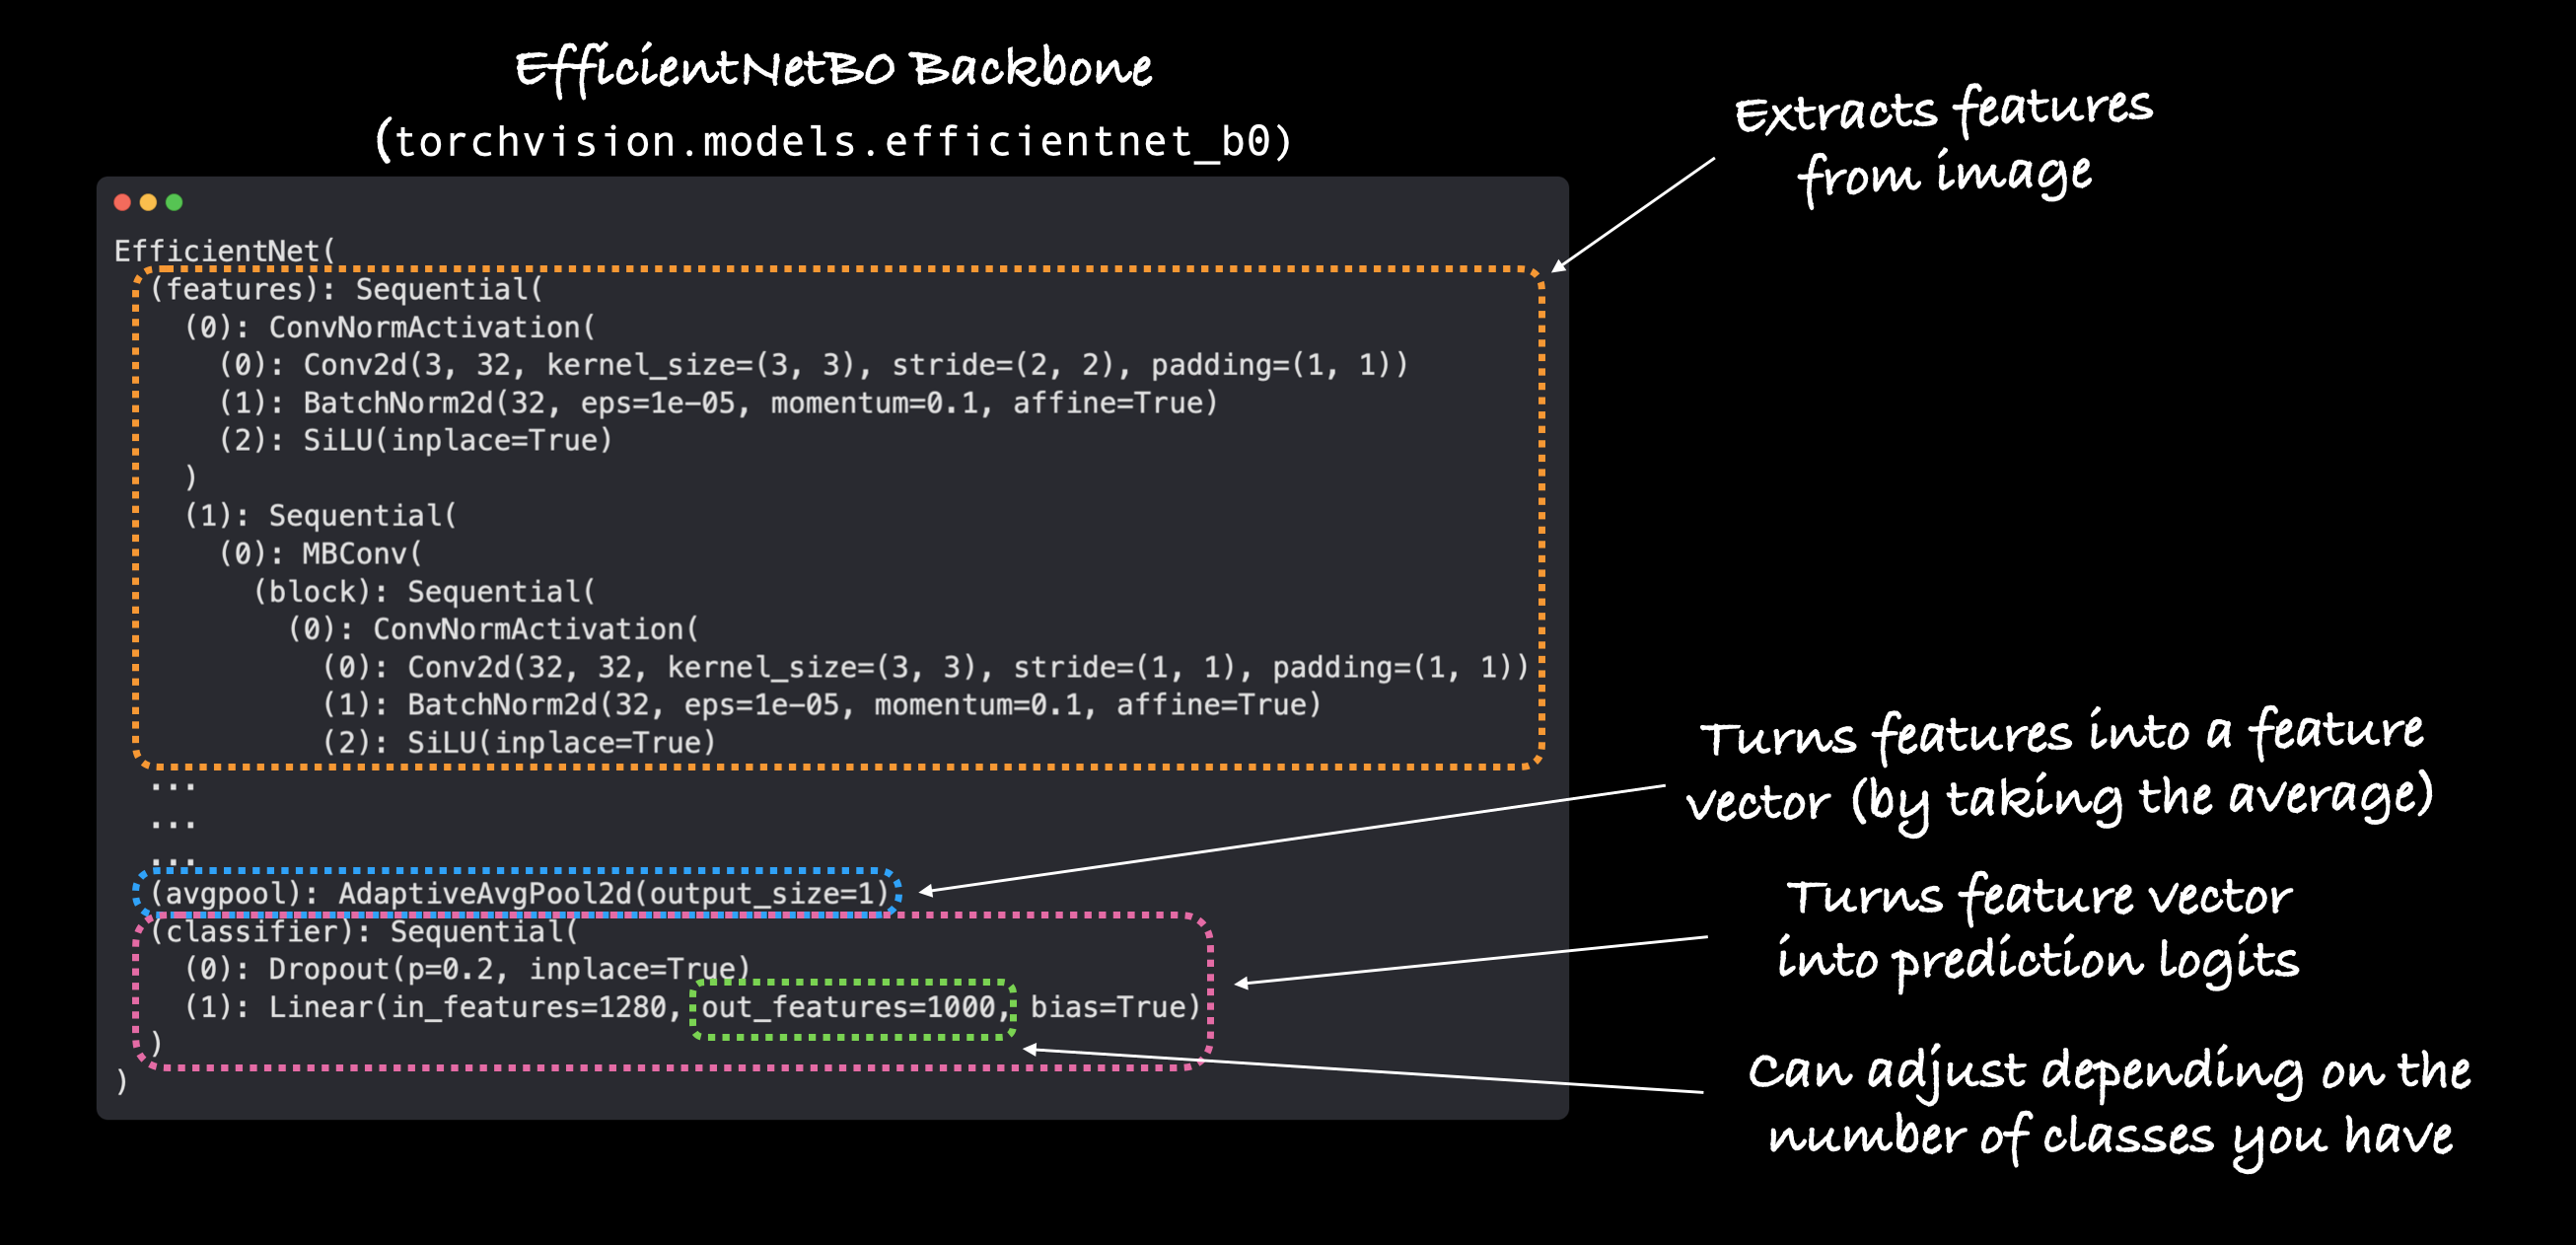

In [158]:
from torchinfo import summary

summary(model=model,
        input_size=(1,3,224,224),#batchsize,color,heigth,width
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 1000]            --                   True
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   True
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   True
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    864                  True
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    64                   True
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 16, 112,

##Freezing the base model and changing the output layer to suit our model

In [159]:
for param in model.features.parameters():
  #print(param)

  param.requires_grad=False


In [160]:
summary(model=model,
        input_size=(1,3,224,224),#batchsize,color,heigth,width
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 1000]            --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

In [161]:
#update the classifer head of our model to suit problem


from torch import nn

model.classifier = nn.Sequential(
    nn.Dropout(p=0.2,inplace=True),
    nn.Linear(in_features=1280,
              out_features=len(class_names)).to(device)
)
model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=3, bias=True)
)

In [162]:
summary(model)

Layer (type:depth-idx)                                  Param #
EfficientNet                                            --
├─Sequential: 1-1                                       --
│    └─Conv2dNormActivation: 2-1                        --
│    │    └─Conv2d: 3-1                                 (864)
│    │    └─BatchNorm2d: 3-2                            (64)
│    │    └─SiLU: 3-3                                   --
│    └─Sequential: 2-2                                  --
│    │    └─MBConv: 3-4                                 (1,448)
│    └─Sequential: 2-3                                  --
│    │    └─MBConv: 3-5                                 (6,004)
│    │    └─MBConv: 3-6                                 (10,710)
│    └─Sequential: 2-4                                  --
│    │    └─MBConv: 3-7                                 (15,350)
│    │    └─MBConv: 3-8                                 (31,290)
│    └─Sequential: 2-5                                  --
│    │    └─MBConv

##Train model

In [163]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [164]:
from timeit import default_timer as timer

start_time = timer()

results = engine.train(model=model,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=10,
                       device=device)

end_time = timer()
print(f"[INFO] Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1140 | train_acc: 0.3711 | test_loss: 0.8569 | test_acc: 0.8144
Epoch: 2 | train_loss: 0.8973 | train_acc: 0.7656 | test_loss: 0.7996 | test_acc: 0.7860
Epoch: 3 | train_loss: 0.8501 | train_acc: 0.6367 | test_loss: 0.6914 | test_acc: 0.8153
Epoch: 4 | train_loss: 0.7365 | train_acc: 0.7227 | test_loss: 0.6726 | test_acc: 0.7746
Epoch: 5 | train_loss: 0.6417 | train_acc: 0.8672 | test_loss: 0.5888 | test_acc: 0.8456
Epoch: 6 | train_loss: 0.6627 | train_acc: 0.7695 | test_loss: 0.5676 | test_acc: 0.8561
Epoch: 7 | train_loss: 0.5846 | train_acc: 0.7500 | test_loss: 0.4814 | test_acc: 0.8968
Epoch: 8 | train_loss: 0.5501 | train_acc: 0.8633 | test_loss: 0.4372 | test_acc: 0.9167
Epoch: 9 | train_loss: 0.5850 | train_acc: 0.7344 | test_loss: 0.4296 | test_acc: 0.8759
Epoch: 10 | train_loss: 0.4964 | train_acc: 0.7969 | test_loss: 0.4590 | test_acc: 0.8769
[INFO] Total training time: 32.250 seconds


In [165]:
results

{'train_loss': [1.1140469387173653,
  0.897304005920887,
  0.8500617668032646,
  0.7364949211478233,
  0.6417126059532166,
  0.6627150699496269,
  0.5845855176448822,
  0.5500577166676521,
  0.5850189849734306,
  0.4964204579591751],
 'train_acc': [0.37109375,
  0.765625,
  0.63671875,
  0.72265625,
  0.8671875,
  0.76953125,
  0.75,
  0.86328125,
  0.734375,
  0.796875],
 'test_loss': [0.8568636973698934,
  0.7996312777201334,
  0.6913760105768839,
  0.6726340452829996,
  0.5888261000315348,
  0.5676125486691793,
  0.48140713572502136,
  0.43722841143608093,
  0.4295818308989207,
  0.4590031107266744],
 'test_acc': [0.814393957455953,
  0.7859848539034525,
  0.8153409163157145,
  0.7746212085088094,
  0.845643957455953,
  0.8560606241226196,
  0.8967803120613098,
  0.9166666666666666,
  0.8759469787279764,
  0.876893957455953]}

In [166]:
from typing import Dict, List

def plot_loss_curves(results:Dict[str, List[float]]):

    loss = results["train_loss"]
    test_loss = results["test_loss"]

    accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]
    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(15, 7))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label="train_accuracy")
    plt.plot(epochs, test_accuracy, label="test_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

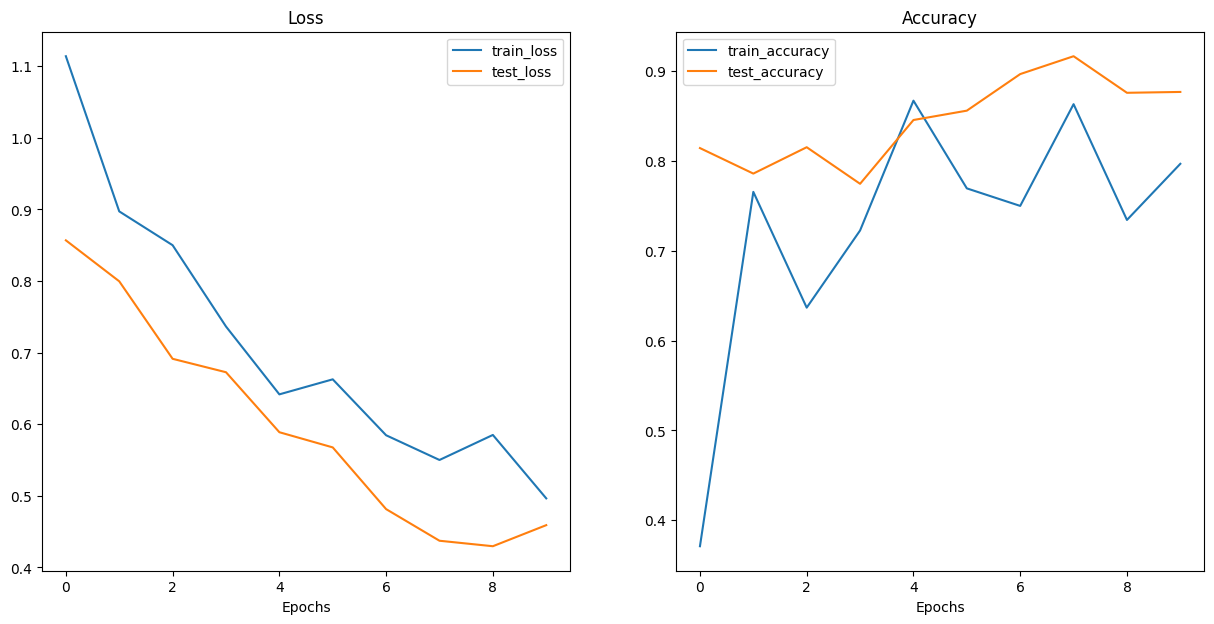

In [167]:
plot_loss_curves(results)

In [168]:
from typing import List,Tuple

from PIL import Image

def pred_and_plot_image(model:torch.nn.Module,
                        image_path:str,
                        class_names:List[str],
                        image_size:Tuple[int,int]=(224,224),
                        transform:torchvision.transforms=None,
                        device:torch.device=device):

  img = Image.open(image_path)

  if transforms is not None:
    image_transform = transform

  else:
    image_transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
    ])


  model.to(device)

  model.eval()

  with torch.inference_mode():

    transform_image = image_transform(img).unsqueeze(dim=0)

    target_image_pred = model(transform_image.to(device))

    target_image_pred_probs = torch.softmax(target_image_pred,dim=1)

    target_image_pred_label = torch.argmax(target_image_pred_probs,dim=1)

    plt.figure()
    plt.imshow(img)
    plt.title(f"Pred: {class_names[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.3f}")
    plt.axis(False);


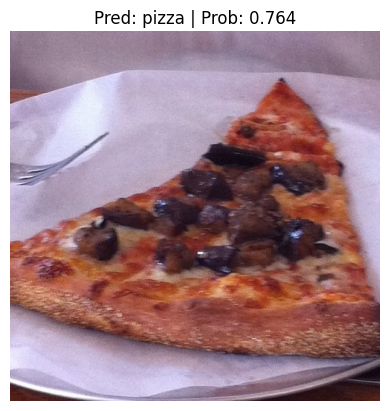

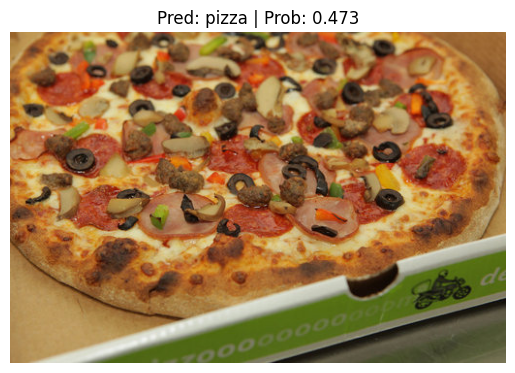

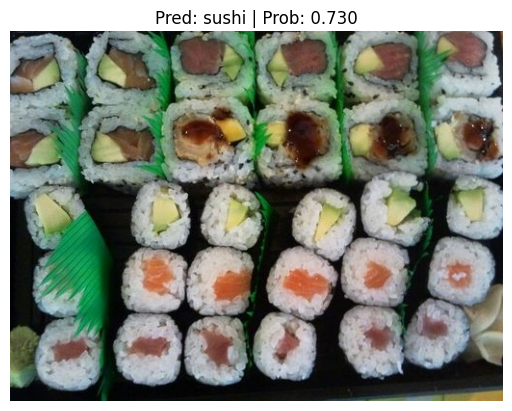

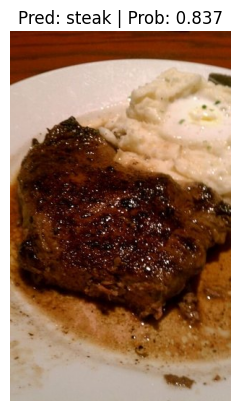

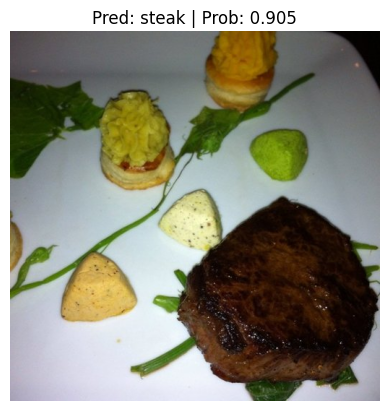

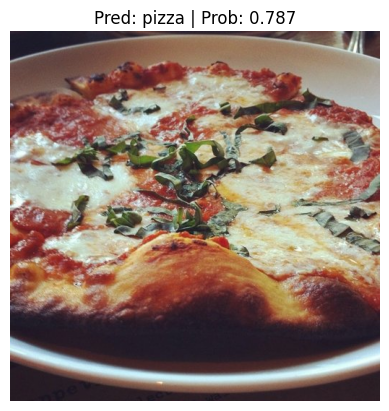

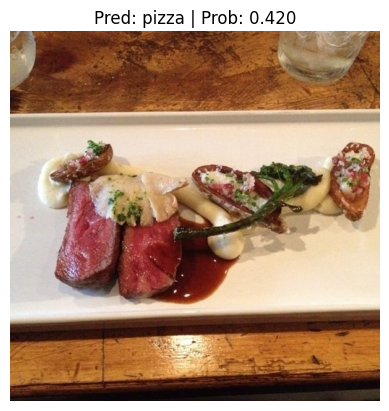

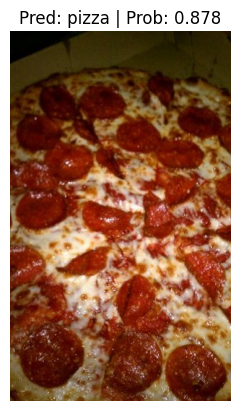

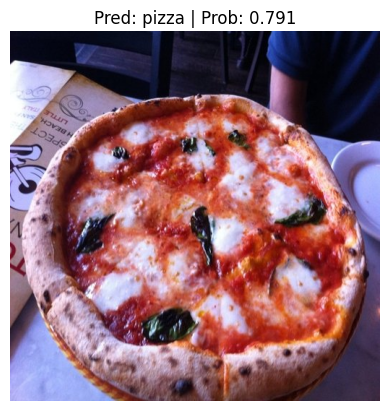

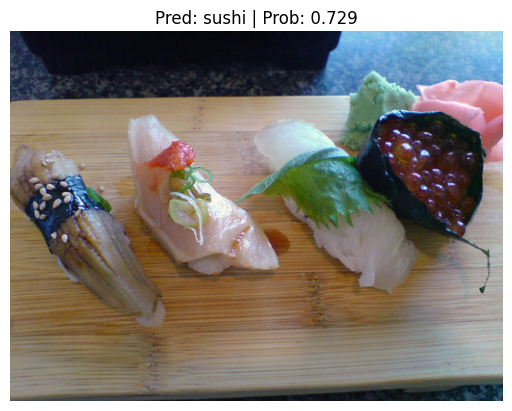

In [169]:
import random

num_images_to_plot = 10

test_image_path_list = list(Path(test_dir).glob("*/*.jpg"))

test_image_path_sample = random.sample(population=test_image_path_list,
                                       k=num_images_to_plot)

for image_path in test_image_path_sample:
  pred_and_plot_image(model=model,
                      image_path=image_path,
                      class_names=class_names,
                      image_size=(224,224),
                      transform=auto_transforms)



data/img_01.jpeg already exists, skipping download.


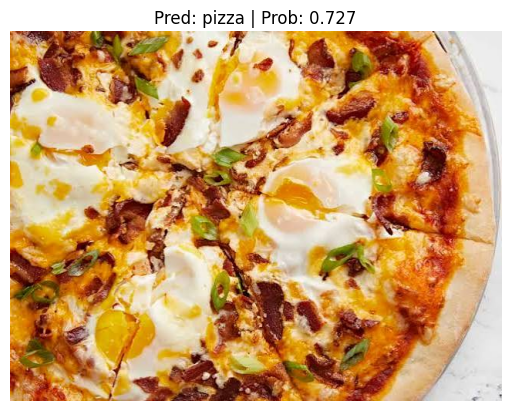

In [170]:
import requests


custom_image_path =   data_path/"img_01.jpeg"


if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        request = requests.get("https://raw.githubusercontent.com/sachinthadilshann/pytorch_course_by_DanielBourke/refs/heads/main/img_01.jpeg")
        print(f"Downloading {custom_image_path}...")
        f.write(request.content)
else:
    print(f"{custom_image_path} already exists, skipping download.")

pred_and_plot_image(model=model,
                    image_path=custom_image_path,
                    class_names=class_names,
                    transform=auto_transforms)